<a href="https://colab.research.google.com/github/safoolady23-wq/AIN-SA2-PartB/blob/main/AIN_SA2_PartB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [165]:
import os
import string
import nltk
import matplotlib.pyplot as plt
from collections import Counter
nltk.download('stopwords')
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
victorizer = CountVectorizer()

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [171]:
with open("ship-timber-date.txt", "r", encoding="utf-8") as file:
    ship_text = file.read()# read ship timer article textual data from files for NLP processing

with open("ai-trainers.txt", "r", encoding="utf-8") as file:
    ai_text = file.read() # read AI trainer article textual data from files for NLP processing

documents = [ship_text, ai_text]

In [191]:

stop_words = set(stopwords.words("english"))

def clean_text(text):
  """
  Clean text by
  -converting lowercase - removing punctuation -removing stopwords
  """
  text = text.lower()
  words = text.split()
  words = [word for word in words if word not in stop_words]
  return " ".join(words)

documents = [ship_text, ai_text]
cleaned_docs = [clean_text(doc) for doc in documents]

In [199]:
vectorizer = CountVectorizer(max_features = 100)
X = vectorizer.fit_transform(cleaned_docs)
#feature_names = vectorizer.get_feature_names_out()
vectors = vectorizer.fit_transform(cleaned_text)

feature_names = vectorizer.get_feature_names_out()
#print(feature_names)

In [200]:
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(vectors)

feature_names = vectorizer.get_feature_names_out()

In [201]:
import numpy as np

def get_top_words(doc_index, X, feature_names, top_n=10):
  """
  Return  top N most frequent words for document
  """
  row = X[doc_index].toarray().flatten()

  top_indices = row.argsort()[-top_n:][::-1]
  top_words = [(feature_names[i], row [i]) for i in top_indices]
  return top_words # looks for the top 10 most frequent words

In [161]:
def get_top_n_words(tokens, n=None):
    """Return the top n words from the frequency tokens."""
    # returns the top 10 words from  the ship and AI articles
    counter = Counter(tokens)
    return counter.most_common(n)
    ship_top_words = get_top_n_words(ship_tokens,10)
    ai_top10_words = get_top_n_words(ai_tokens, 10)
    print("Top 10 words in ship article:")
    print(ship_top_words)
    print("\nTop 10 words in AI article:")
    print(ai_top10_words)

In [203]:
ship_top = get_top_words(0, vectors, feature_names,10)
ai_top = get_top_words(1, vectors, feature_names,10)

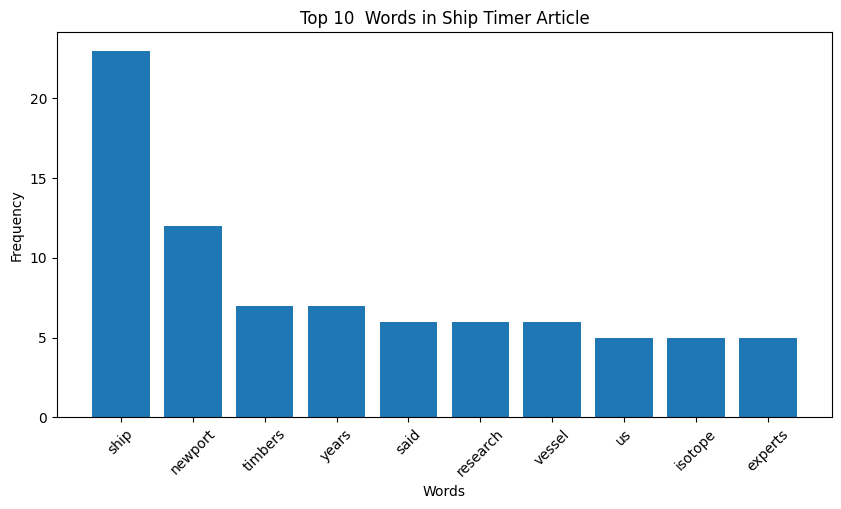

In [150]:
words, counts = zip(*ship_top)

plt.figure(figsize=(10,5)) # the bar grapg is showing the top 10 words in the ship article
plt.bar(words, counts)
plt.title("Top 10  Words in Ship Timer Article")
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

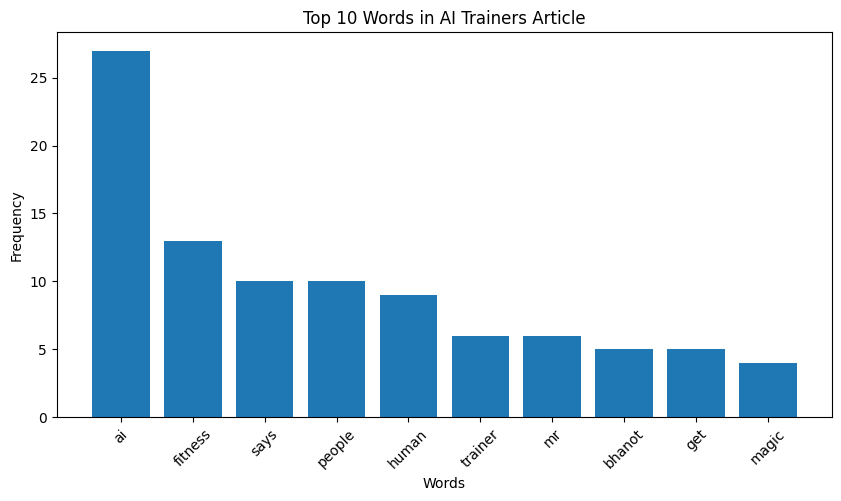

In [158]:
words, counts = zip(*ai_top)

plt.figure(figsize=(10,5))
plt.bar(words, counts) # the plot graph is shoing the top 10 words in the ai article
plt.title("Top 10 Words in AI Trainers Article")
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


In [204]:
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(vectors)

LatentDirichletAllocation(n_components=3, random_state=42)

In [212]:
def get_topic_words(model, feature_names, n_top_words=10):
  topic_data =[]
  """
  Extract top words for each topic in the LDA model.
  """

  for topic_idx, topic in enumerate(model.components_):
    top_indices = topic.argsort()[-n_top_words:][::-1]
    words = [feature_names[i] for i in top_indices]
    weights = [topic[i] for i in top_indices]

    topics.append((words, weights))
  # Move return statement outside the loop to gather all topics
  return topics

# Call the function with the correct LDA model (lda) and feature_names
topics = get_topic_words(lda, feature_names, 10)

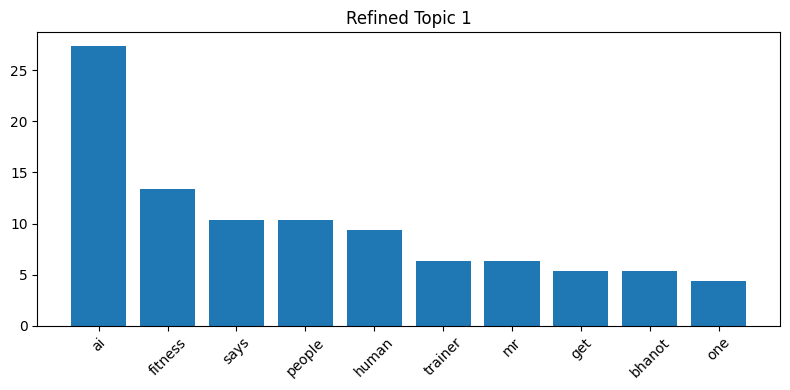

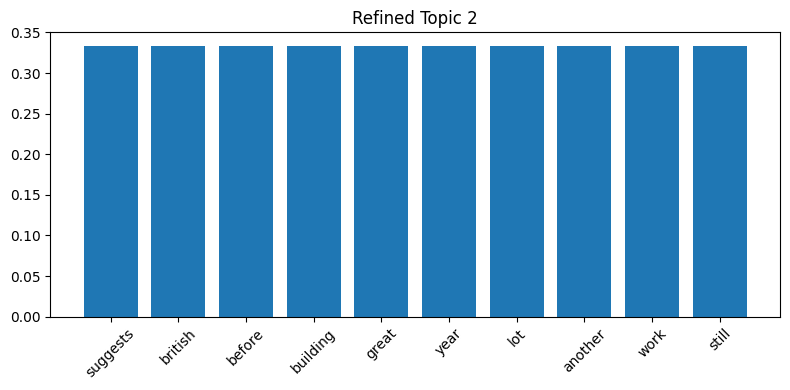

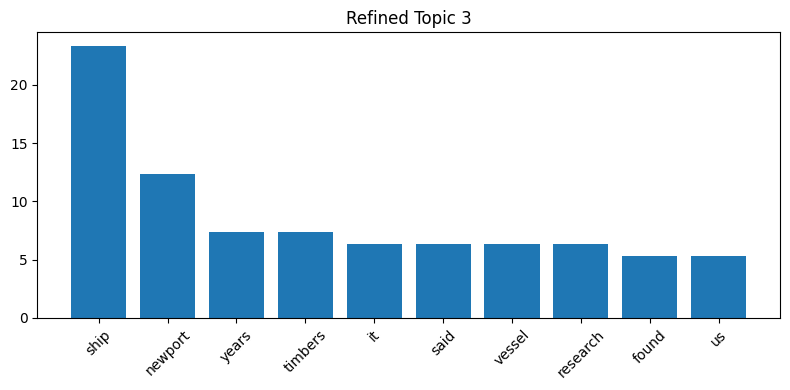

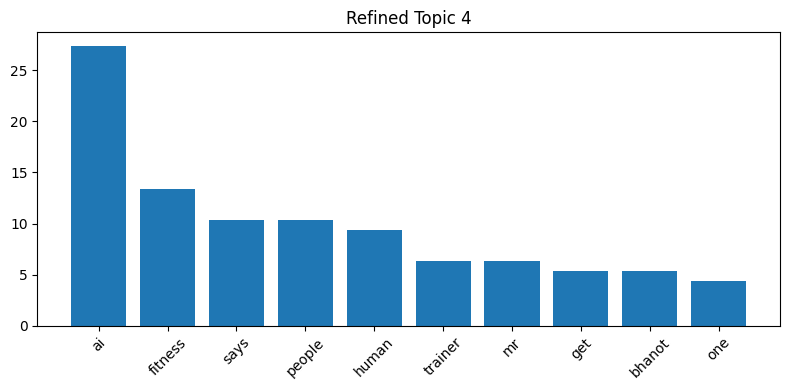

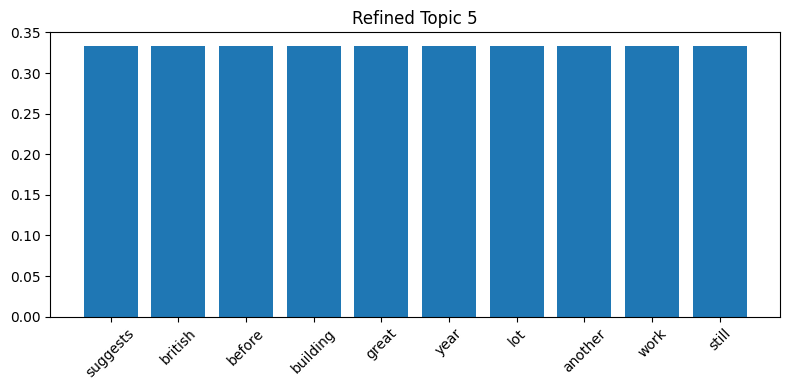

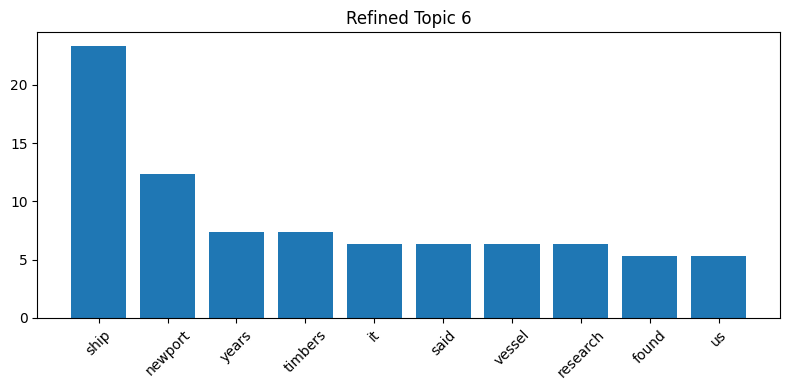

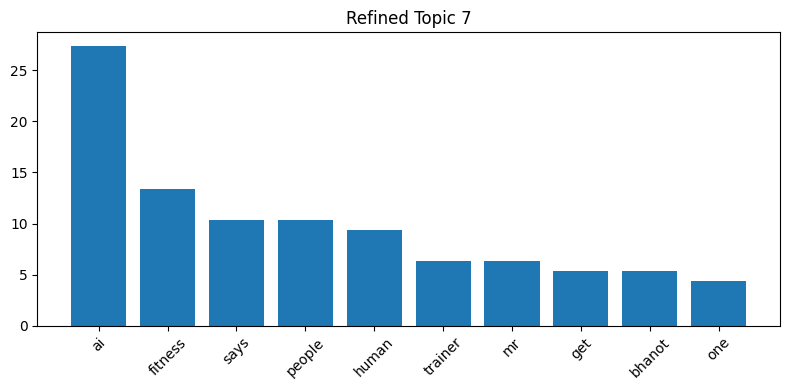

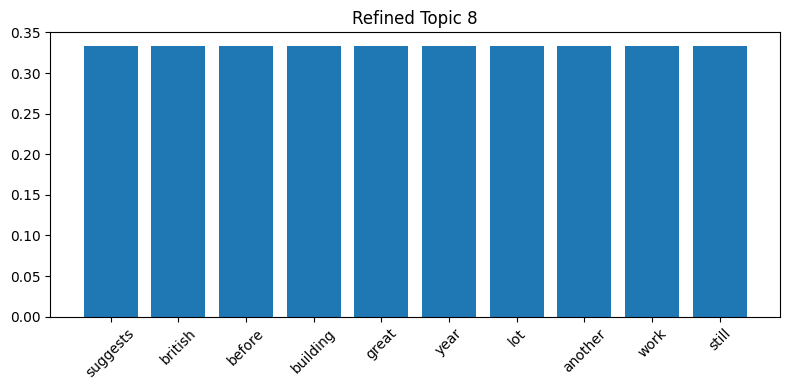

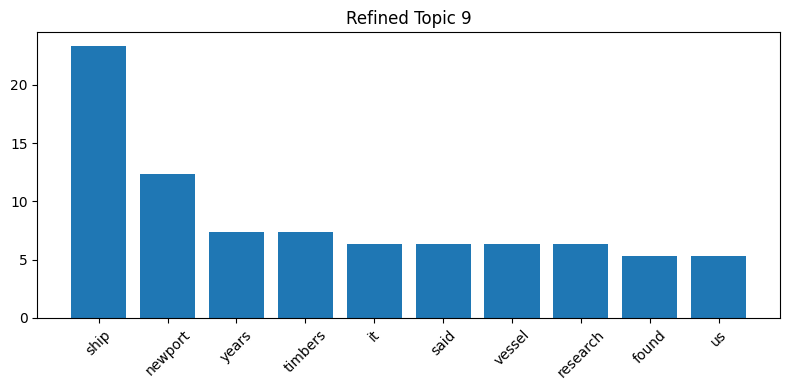

In [213]:
import matplotlib.pyplot as plt

for i, (words, weights) in enumerate(topics):
  plt.figure(figsize=(8,4))
  plt.bar(words, weights)
  plt.title(f"Refined Topic {i+1}")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

In [215]:
doc_topic_dist = lda.transform(X)

for i, dist in enumerate(doc_topic_dist):
  print(f"\nArticle {i+1} topic distribution")

  for topic_num, prob in enumerate(dist):
    print(f"Topic {topic_num+1}: {prob:.3f}")

    print(f"Most likely topic: Topic {dist.argmax() +1}")
    #Fatching the top 3 topics in the articles


Article 1 topic distribution
Topic 1: 0.001
Most likely topic: Topic 3
Topic 2: 0.001
Most likely topic: Topic 3
Topic 3: 0.997
Most likely topic: Topic 3

Article 2 topic distribution
Topic 1: 0.996
Most likely topic: Topic 1
Topic 2: 0.002
Most likely topic: Topic 1
Topic 3: 0.002
Most likely topic: Topic 1


In [228]:
def get_top_words(doc_index, X, feature_names, n=3):
    ##"""Plot a bar chart of the top words."""

    row = X[doc_index].toarray().flatten()
    top_indices = row.argsort()[-n:][::-1]

    return [(feature_names[i], row[i]) for i in top_indices]
    ship_top_words = get_top_words(0, X, feature_names, n=3)
    ai_top_words = get_top_words(1, X, feature_names, n=3)


   # Fetching the top 3 topics from the ship text data
    words, counts = zip(*ship_top_3)
    plt.figure(figsize=(6,4))
    plt.bar(words, counts)
    plt.title("Top 3 topics - ship Article")
    plt.show()


    # Fetching the top 3 topics from the AI trainer text data
    words, counts = zip(*ship_top_3)
    plt.figure(figsize=(6,4))
    plt.bar(words, counts)
    plt.title("Top 3 topics - ai trianer Article")
    plt.show()



In [257]:
def generate_summary(top_words):

# (doc_index, X, feature_names, n=3):
    """
    Generate s summery of sentence dicribing what the article is about.
    """
    words = [word for word, count in top_words]
    return f"This article is about {' '.join(words[:3])}."

print ("\n---Final interpretation---")
print("Ship Article", generate_summary(ship_top_words))
print("AI Trainer Article", generate_summary(ai_top_words))



---Final interpretation---
Ship Article This article is about ship newport timbers.
AI Trainer Article This article is about ai fitness people.


In [258]:

try:
    _ = ship_text
except NameError:
    ship_text = "This is dummy text for ship timber data."
    ai_text = "This is dummy text for ai trainers data."

corpus = [ship_text, ai_text]
vectorizer = CountVectorizer(stop_words="english", max_features=50)
X = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()

ship_counts = dict(zip(feature_names, X.toarray()[0]))
ai_counts = dict(zip(feature_names, X.toarray()[1]))

def top_n_from_dict(d, n=3):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:n]

ship_top_words = top_n_from_dict(ship_counts, n=3)
ai_top_words = top_n_from_dict(ai_counts, n=3)

print("Top 3 words in ship article:")
print(ship_top_words)
print("\nTop 3 words in AI article:")
print(ai_top_words)

Top 3 words in ship article:
[('ship', np.int64(23)), ('newport', np.int64(12)), ('timbers', np.int64(7))]

Top 3 words in AI article:
[('ai', np.int64(27)), ('fitness', np.int64(13)), ('people', np.int64(10))]


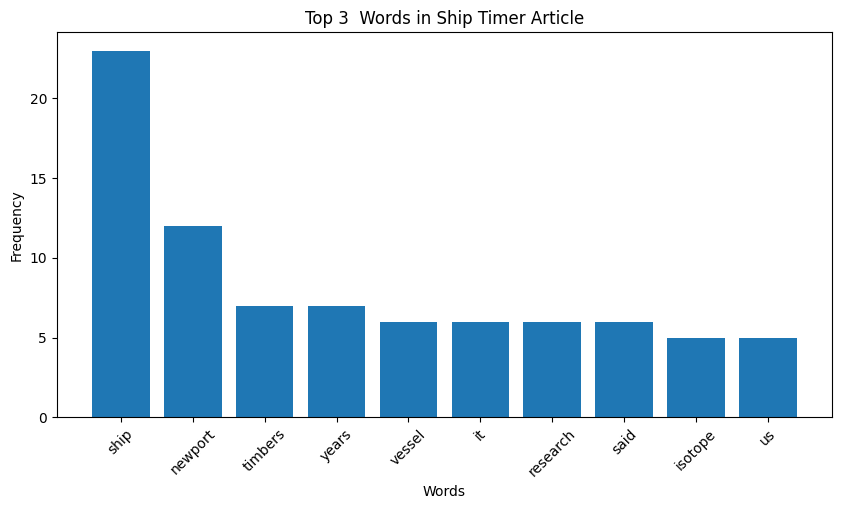

In [259]:
import matplotlib.pyplot as plt

ship_counts = dict(zip(feature_names, X.toarray()[0]))
ai_counts = dict(zip(feature_names, X.toarray()[1]))

def top_n_from_dict(d, n=3):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:n]

ship_top_words = top_n_from_dict(ship_counts, n=3)
ai_top_words = top_n_from_dict(ai_counts, n=3)

words, counts = zip(*ship_top)

plt.figure(figsize=(10,5)) # the bar grapg is showing the top 10 words in the ship article
plt.bar(words, counts)
plt.title("Top 3  Words in Ship Timer Article")
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()



